In [1]:
from pydantic import JsonValue
from typing import Any, cast

from inspect_ai.analysis import Column, EvalColumn, SampleColumn, samples_df


def score_values(x: JsonValue) -> dict[str, JsonValue]:
    scores = cast(dict[str, Any], x)
    return {k: v["value"] for k, v in scores.items()}

columns: list[Column] = [
    EvalColumn("model", path="eval.model", required=True),
    SampleColumn("epoch", path="epoch", required=True),
    SampleColumn("score_*", path="scores", value=score_values),
]

df = samples_df(
    logs="logs/2025-09-28_12-53-55",
    columns=columns,
)

# is there a better way to do this using Inspect?
df = df.drop(columns=["score_pct_turns_absolutely_correct", "score_pct_turns_relatively_correct", "score_turn_relatively_correct"])

In [2]:
df.head(5)

,sample_id,eval_id,model,log,epoch,score_max_turn_absolutely_correct,score_turn_absolutely_correct
0,Ufm2yTFQQJEwyqJioLBJaf,DtRcntpjJFmT64t2DKQy2B,openai/gpt-4.1-nano-2025-04-14,/home/ubuntu/long-horizon-execution/logs/2025-...,3,2,"{""1"": true, ""2"": true, ""3"": false, ""4"": false,..."
1,GMZC4hKJM62GVe75pQZd2M,DtRcntpjJFmT64t2DKQy2B,openai/gpt-4.1-nano-2025-04-14,/home/ubuntu/long-horizon-execution/logs/2025-...,2,2,"{""1"": true, ""2"": true, ""3"": false, ""4"": false,..."
2,S9QLsJv9XSQHXXYq579rup,DtRcntpjJFmT64t2DKQy2B,openai/gpt-4.1-nano-2025-04-14,/home/ubuntu/long-horizon-execution/logs/2025-...,1,2,"{""1"": true, ""2"": true, ""3"": false, ""4"": false,..."
3,9voFMvqgxLwjJ3wZa2EKvm,a9WeipsTHKCo6TKp95pph2,anthropic/claude-3-5-haiku-20241022,/home/ubuntu/long-horizon-execution/logs/2025-...,2,1000,"{""1"": true, ""2"": true, ""3"": true, ""4"": true, ""..."
4,GyoSBKHmJ9HKW3k3qN89SS,a9WeipsTHKCo6TKp95pph2,anthropic/claude-3-5-haiku-20241022,/home/ubuntu/long-horizon-execution/logs/2025-...,1,1000,"{""1"": true, ""2"": true, ""3"": true, ""4"": true, ""..."


In [3]:
import json

df['score_turn_absolutely_correct'] = df['score_turn_absolutely_correct'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

In [4]:
import pandas as pd

expanded_data = []
for _, row in df.iterrows():
    base_row = row.drop('score_turn_absolutely_correct').to_dict()
    for turn, is_correct in row['score_turn_absolutely_correct'].items():
        expanded_data.append({
            **base_row,
            'turn': int(turn),
            'is_absolutely_correct': is_correct
        })

df = pd.DataFrame(expanded_data)

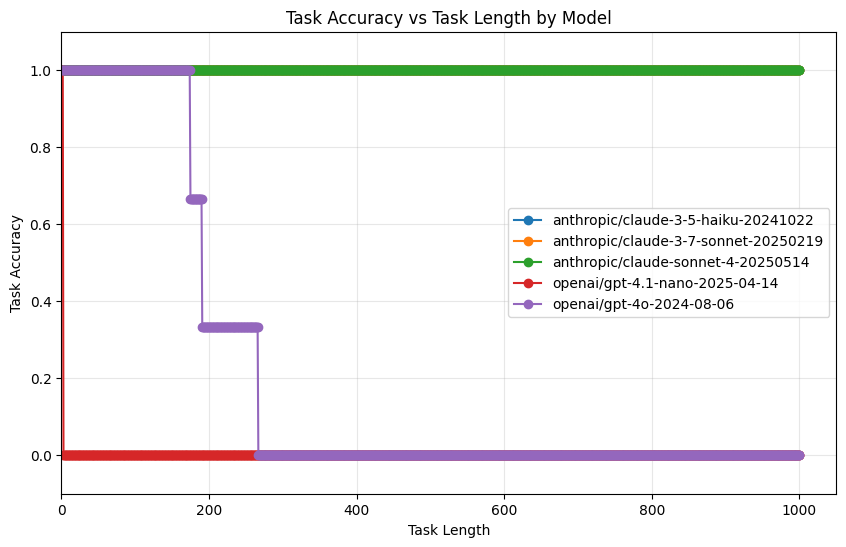

In [5]:
import matplotlib.pyplot as plt

plot_data = df.groupby(['model', 'turn'])['is_absolutely_correct'].agg(['mean', 'count']).reset_index()
plot_data.columns = ['model', 'turn', 'task_accuracy', 'n_samples']

plt.figure(figsize=(10, 6))
for model in plot_data['model'].unique():
    model_data = plot_data[plot_data['model'] == model].sort_values('turn')
    plt.plot(model_data['turn'], model_data['task_accuracy'], marker='o', label=model)

plt.xlabel('Task Length')
plt.ylabel('Task Accuracy')
plt.title('Task Accuracy vs Task Length by Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, None)
plt.ylim(-0.1, 1.1)
plt.show()